In [81]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-

# Deep Neural Network

## Template 03
## FIFA dataset Using PYTORCH

<img src='../../prasami_images/prasami_color_tutorials_small.png' width='400' alt="By Pramod Sharma : pramod.sharma@prasami.com"/>

In [82]:
###-----------------
### Import libraries
###-----------------

import numpy as np  # Import NumPy for numerical computations and array operations
import pandas as pd  # Import Pandas for data manipulation and analysis with DataFrames
import matplotlib.pyplot as plt  # Import Matplotlib for creating static, interactive visualizations
import seaborn as sns  # Import Seaborn for statistical data visualization built on Matplotlib
from pathlib import Path

from sklearn.model_selection import train_test_split  # Import function to split dataset into training and testing subsets
from sklearn.metrics import (accuracy_score, classification_report, 
                             confusion_matrix, ConfusionMatrixDisplay, f1_score)  # Import function to calculate various metric

from sklearn.preprocessing import StandardScaler, LabelEncoder  # Import for standardizing features (zero mean, unit variance)

import torch
import torch.nn as nn  # Import PyTorch's neural network module for building and training neural networks
from torchsummary import summary  # Import function to summarize the model architecture and parameters

In [83]:
###----------------------
### Some basic parameters
###----------------------

inpDir = Path('.. / .. / input')
outDir = Path('.. / .. / output')
subDir = 'D:/Deep_Learning/SharedData'

RANDOM_STATE = 24 # for initialization ----- REMEMBER: to remove at the time of promotion to production
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

TEST_SIZE = 0.2
EPOCHS = 1001 # number of epochs
BATCH_SIZE = 32
ALPHA = 0.001 # learning rate

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') # Use GPU if available, otherwise fallback to CPU
print(f"Using device: {device}")


Using device: cpu


## Read FIFA 2019 data set

In [84]:
# data_df = pd.read_csv('D:/Deep_Learning/SharedData/fifa_2019.csv')
data_df = pd.read_csv(inpDir / subDir / 'wine.csv', header = None)
data_df.shape

(178, 14)

<Axes: >

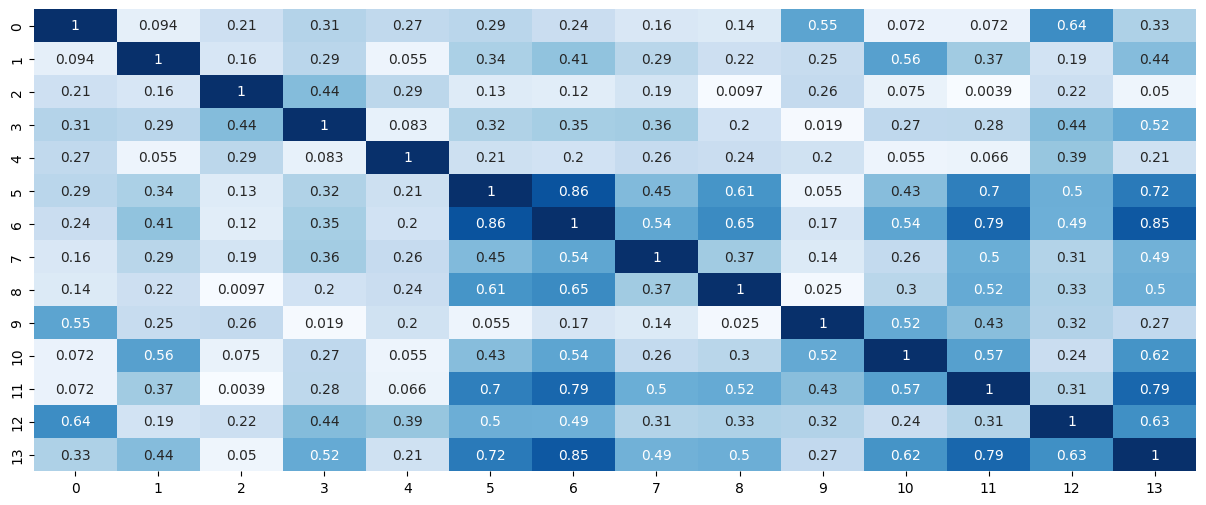

In [85]:
fig, ax = plt.subplots(figsize=(15, 6))

sns.heatmap(data_df.corr().abs(), annot=True, fmt='.2g', 
            cmap='Blues', ax=ax, cbar=False)

In [86]:
labels=data_df[data_df.columns[-1]]
features=data_df.drop(columns=data_df.columns[-1])
features.shape, labels.shape

((178, 13), (178,))

In [87]:
X_train,X_test,y_train,y_test = train_test_split(features,labels,
                                                 test_size=TEST_SIZE,
                                                 random_state=RANDOM_STATE,
                                                 stratify=labels)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((142, 13), (142,), (36, 13), (36,))

In [88]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [89]:
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

In [90]:
model = nn.Sequential(
   nn.Linear(in_features=X_train.shape[1], out_features=8),        # Input layer to hidden layer with 64 neurons
   nn.ReLU(),               # Activation function for hidden layer
   nn.Linear(in_features=8, out_features=3),            # Hidden layer to another hidden layer with 32 neurons       
)

display(model)

Sequential(
  (0): Linear(in_features=13, out_features=8, bias=True)
  (1): ReLU()
  (2): Linear(in_features=8, out_features=3, bias=True)
)

In [91]:
# model = model.to(device) # Move the model to the specified device (GPU)

In [92]:
summary(model, input_size=(X_train.shape[1], ))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                    [-1, 8]             112
              ReLU-2                    [-1, 8]               0
            Linear-3                    [-1, 3]              27
Total params: 139
Trainable params: 139
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00
----------------------------------------------------------------


In [93]:
print(f'Total Parameters: {sum(p.numel() for p in model.parameters())}')
print(f'Layer 1 Weights :{list(model.parameters())[0].shape}')
print(f'Layer 1 Biases :{list(model.parameters())[1].shape}')
print(f'Layer 2 Weights :{list(model.parameters())[2].shape}')
print(f'Layer 2 Biases :{list(model.parameters())[3].shape}')

Total Parameters: 139
Layer 1 Weights :torch.Size([8, 13])
Layer 1 Biases :torch.Size([8])
Layer 2 Weights :torch.Size([3, 8])
Layer 2 Biases :torch.Size([3])


In [94]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr = ALPHA)

In [95]:
train_x = torch.tensor(X_train, dtype= torch.float32, device=device)
train_y = torch.tensor(y_train, dtype= torch.int64, device=device)

test_x = torch.tensor(X_test, dtype= torch.float32, device=device)
test_y = torch.tensor(y_test, dtype= torch.int64, device=device)


## Unit Testing

In [96]:
pred = model(train_x[:1])
pred

tensor([[ 0.3531, -0.3311, -0.2378]], grad_fn=<AddmmBackward0>)

In [97]:
loss_fn(pred, train_y[:1])

tensor(1.4061, grad_fn=<NllLossBackward0>)

## Training Loop

In [98]:
for epoch in range(EPOCHS):
    model.train()
    
    pred = model(train_x) # forward pass
    loss = loss_fn(pred, train_y)
    
    optimizer.zero_grad()       # reset gradients to zero
    loss.backward()             # backpropogation to compute gradients
    optimizer.step()            # update model parameters using optimizer
    
    if epoch % 100 == 0:
        print(f'Epoch: {epoch:5d} | Loss: {loss.item():.6f}')
    

Epoch:     0 | Loss: 1.111255
Epoch:   100 | Loss: 0.618845
Epoch:   200 | Loss: 0.263594
Epoch:   300 | Loss: 0.123605
Epoch:   400 | Loss: 0.076076
Epoch:   500 | Loss: 0.053684
Epoch:   600 | Loss: 0.040487
Epoch:   700 | Loss: 0.031749
Epoch:   800 | Loss: 0.025499
Epoch:   900 | Loss: 0.020458
Epoch:  1000 | Loss: 0.016340


## Prediction

In [99]:
model.eval()

with torch.inference_mode():
    train_pred = model(train_x).argmax(dim=1)
    test_pred = model(test_x).argmax(dim=1)

In [100]:
train_pred.shape, test_pred.shape

(torch.Size([142]), torch.Size([36]))

In [101]:
y_train_pred = train_pred.detach()  # remove from computaional graph
# y_train_pred = y_train_pred.cpu().numpy()  # move to cpu if on gpu

type(y_train_pred), y_train_pred.shape


(torch.Tensor, torch.Size([142]))

In [102]:
print(classification_report(y_train, y_train_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        47
           1       1.00      1.00      1.00        57
           2       1.00      1.00      1.00        38

    accuracy                           1.00       142
   macro avg       1.00      1.00      1.00       142
weighted avg       1.00      1.00      1.00       142



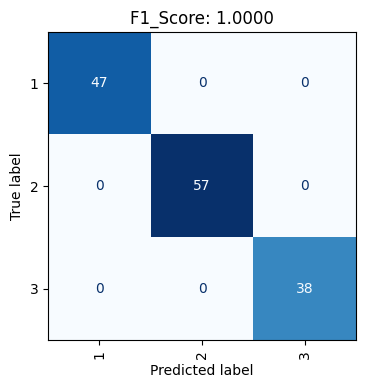

In [103]:
cm = confusion_matrix(y_train, y_train_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[1,2,3])

fig, ax = plt.subplots(figsize = (4,4))

disp.plot(ax=ax, cmap='Blues',  xticks_rotation = 'vertical', colorbar=False)
# Disable the grid
ax.grid(False)
ax.set_title(f"F1_Score: {f1_score(y_train, y_train_pred, average='weighted'):0.4f}")
plt.show()

## Predictions on test_ds

In [104]:
y_test_pred = test_pred.detach()  # remove from computaional graph
# y_train_pred = y_train_pred.cpu().numpy()  # move to cpu if on gpu

type(y_test_pred), y_test_pred.shape

(torch.Tensor, torch.Size([36]))

In [105]:
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



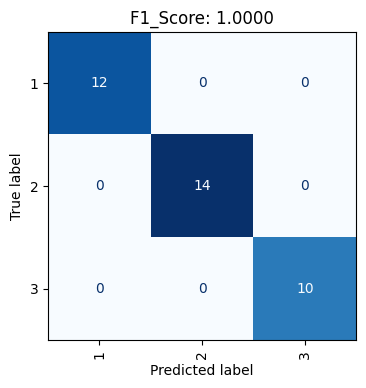

In [106]:
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[1,2,3])

fig, ax = plt.subplots(figsize = (4,4))

disp.plot(ax=ax, cmap='Blues',  xticks_rotation = 'vertical', colorbar=False)
# Disable the grid
ax.grid(False)
ax.set_title(f"F1_Score: {f1_score(y_test, y_test_pred, average='weighted'):0.4f}")
plt.show()

# Track Progress

In [107]:
train_loss, test_loss =  [], []

for epoch in range(EPOCHS):
    model.train()    # set the model to training mode
       
    # forward pass
    pred = model(train_x) # forward pass
    loss = loss_fn(pred, train_y)
    
    # back propogation and optimization
    optimizer.zero_grad()       # reset gradients to zero
    loss.backward()             # backpropogation to compute gradients
    optimizer.step()            # update model parameters using optimizer
    
    train_loss.append(loss.item())
    
    # evaluate on test data
    model.eval()
    with torch.inference_mode():
        test_pred = model(test_x)
    
    tloss = loss_fn(test_pred, test_y)
    test_loss.append(tloss.item())
    
    
    if epoch % 100 == 0:
        print(f'Epoch: {epoch:5d} | Train Loss: {loss.item():.6f} | Test Loss: {tloss.item():.6f}')
    

Epoch:     0 | Train Loss: 0.016305 | Test Loss: 0.021347
Epoch:   100 | Train Loss: 0.013549 | Test Loss: 0.018501
Epoch:   200 | Train Loss: 0.011444 | Test Loss: 0.016358
Epoch:   300 | Train Loss: 0.009761 | Test Loss: 0.014610
Epoch:   400 | Train Loss: 0.008391 | Test Loss: 0.013188
Epoch:   500 | Train Loss: 0.007262 | Test Loss: 0.012027
Epoch:   600 | Train Loss: 0.006324 | Test Loss: 0.011059
Epoch:   700 | Train Loss: 0.005544 | Test Loss: 0.010111
Epoch:   800 | Train Loss: 0.004887 | Test Loss: 0.009246
Epoch:   900 | Train Loss: 0.004328 | Test Loss: 0.008497
Epoch:  1000 | Train Loss: 0.003849 | Test Loss: 0.007863
